In [1]:
!gdown --fuzzy https://drive.google.com/file/d/1jgys2TpiZ-BJhNwB-axepvkw0Cc0mYTb/view?usp=sharing
!unzip -q dl_4.zip
!rm dl_4.zip

Downloading...
From (original): https://drive.google.com/uc?id=1jgys2TpiZ-BJhNwB-axepvkw0Cc0mYTb
From (redirected): https://drive.google.com/uc?id=1jgys2TpiZ-BJhNwB-axepvkw0Cc0mYTb&confirm=t&uuid=e35fd526-e3bf-4eb6-b633-78d193310665
To: /content/dl_4.zip
100% 21.4M/21.4M [00:00<00:00, 56.0MB/s]


In [5]:
import skimage.io
import skimage
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
dataset_path = '/content/dl_4/'

train_dir = os.path.join(dataset_path, 'train/train')
test_dir = os.path.join(dataset_path, 'test/test')
train_df = pd.read_csv(os.path.join(dataset_path, 'train.csv'))

<Figure size 1500x400 with 0 Axes>

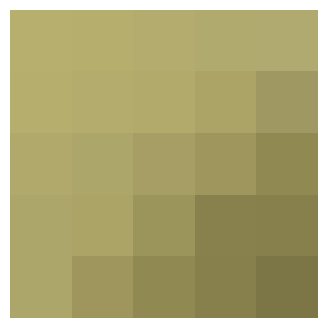

In [12]:
n = 15000
figure = plt.figure(figsize = (15, 4))
background = np.zeros((5, 5, 3))
images_path = '/content/dl_4/train/train/'
for cnt, image_name in enumerate(os.listdir(images_path)):
  if cnt == n:
    break
  image = skimage.io.imread(images_path + image_name)
  background[:5, :5] += image[:5, :5]

background_avg = (background//(n)).astype(np.uint8)
background_avg = cv2.medianBlur(background_avg, 5)
plt.figure(figsize=(6, 4))
plt.imshow(background_avg)
plt.axis('off')
plt.show()

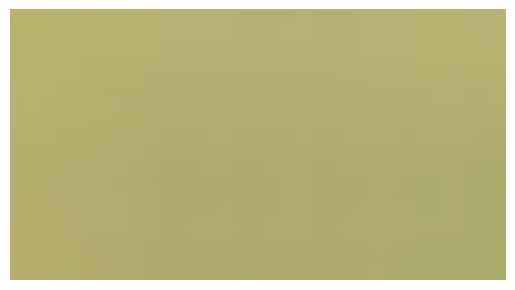

In [13]:
def create_background(back_texture, imgsize=(18, 33, 3), seed=1):
    np.random.seed(seed)
    background = np.zeros(imgsize, dtype=np.uint8)
    texture_shape = back_texture.shape

    cnt_row_full = imgsize[0] // texture_shape[0]
    cnt_col_full = imgsize[1] // texture_shape[1]
    remainder_row = imgsize[0] % texture_shape[0]
    remainder_col = imgsize[1] % texture_shape[1]

    for i in range(cnt_row_full):
        for j in range(cnt_col_full):
            bias = np.random.randint(0, 15, texture_shape, dtype=np.uint8)
            y_start = texture_shape[0] * i
            x_start = texture_shape[1] * j
            background[y_start:y_start + texture_shape[0], x_start:x_start + texture_shape[1]] = ((back_texture + bias) % 255).astype(np.uint8)
    if remainder_col > 0:
        for i in range(cnt_row_full):
            bias = np.random.randint(0, 15, texture_shape, dtype=np.uint8)
            tile = (back_texture.astype(np.int16) + bias) % 255
            y_start = texture_shape[0] * i
            x_start = cnt_col_full * texture_shape[1]
            background[y_start:y_start + texture_shape[0], x_start:x_start + remainder_col] = tile[:, :remainder_col].astype(np.uint8)
    if remainder_row > 0:
        for j in range(cnt_col_full):
            bias = np.random.randint(0, 15, texture_shape, dtype=np.uint8)
            tile = (back_texture.astype(np.int16) + bias) % 255
            y_start = cnt_row_full * texture_shape[0]
            x_start = texture_shape[1] * j
            background[y_start:y_start + remainder_row, x_start:x_start + texture_shape[1]] = tile[:remainder_row, :].astype(np.uint8)
    if remainder_row > 0 and remainder_col > 0:
        bias = np.random.randint(0, 15, texture_shape, dtype=np.uint8)
        tile = (back_texture.astype(np.int16) + bias) % 255
        y_start = cnt_row_full * texture_shape[0]
        x_start = cnt_col_full * texture_shape[1]
        background[y_start:y_start + remainder_row, x_start:x_start + remainder_col] = tile[:remainder_row, :remainder_col].astype(np.uint8)
    background = cv2.medianBlur(background, 19)
    return background

avg_background = create_background(background_avg)
plt.axis('off')
plt.imshow(avg_background)
plt.show()

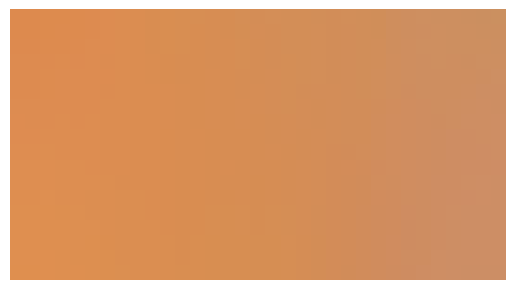

In [14]:
orange_back_imges = ['0_10-B4-1D-C7-FE-64_56_2025-11-16-17-02-10.jpg', '0_10-B4-1D-C7-FE-E8_24_2025-11-14-19-56-13.jpg','0_10-B4-1D-C7-FE-94_7_2025-11-13-11-00-37.jpg', '0_10-B4-1D-C7-FE-64_56_2025-11-16-17-02-10.jpg',
                     '0_10-B4-1D-C8-00-10_16_2025-11-11-11-00-38.jpg', '0_10-B4-1D-C8-0A-28_2026-01-22-22-01-34.jpg', '0_10-B4-1D-C8-0A-90_67_2025-11-14-19-57-49.jpg', '0_10-B4-1D-C8-0A-C4_10_2025-11-11-10-01-12.jpg', '0_10-B4-1D-C8-01-00_40_2025-11-17-19-53-30.jpg' ]
n = len(orange_back_imges)
background = np.zeros((5, 5 *n , 3), dtype=np.uint8)
for cnt, image_name in enumerate(orange_back_imges):
  if cnt == n:
    break
  image = skimage.io.imread(images_path + image_name)
  background[:5, 5*cnt:5*(cnt+1)] = image[:5, :5]

background = cv2.medianBlur(background, 5*n)
orange_background = create_background(background)
plt.axis('off')
plt.imshow(orange_background)
plt.show()

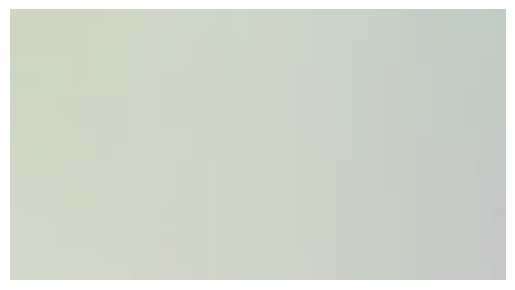

In [15]:
white_back_imges = ['0_10-B4-1D-C8-03-64_11_2025-11-11-19-55-50.jpg', '0_10-B4-1D-C8-03-64_14_2025-11-11-19-55-50.jpg', '0_10-B4-1D-C8-03-FC_13_2025-11-17-11-04-22.jpg',
                    '0_10-B4-1D-C7-F9-9C_10_2025-11-11-19-54-29.jpg', '0_10-B4-1D-C7-FE-14_20_2025-11-15-19-56-54.jpg', '0_10-B4-1D-C8-00-EC_15_2025-11-12-10-02-13.jpg',
                    '0_10-B4-1D-C8-03-2C_33_2025-11-18-11-03-58.jpg']

n = len(white_back_imges)
background = np.zeros((5, 5 *n , 3), dtype=np.uint8)
for cnt, image_name in enumerate(white_back_imges):
  if cnt == n:
    break
  image = skimage.io.imread(images_path + image_name)
  background[:5, 5*cnt:5*(cnt+1)] = image[:5, :5]

background = cv2.medianBlur(background, 55)
white_background = create_background(background)
plt.axis('off')
plt.imshow(white_background)
plt.show()

In [16]:
np.save('/content/avg_background.npy', avg_background)
np.save('/content/orange_background.npy', orange_background)
np.save('/content/white_background.npy', white_background)

In [19]:
!zip -r background.zip /content/avg_background.npy /content/orange_background.npy /content/white_background.npy

  adding: content/avg_background.npy (deflated 65%)
  adding: content/orange_background.npy (deflated 69%)
  adding: content/white_background.npy (deflated 71%)


In [20]:
!zip -r fonts.zip /content/GoogleSans-Bold.ttf /content/Korolev-Bold.otf /content/Lato-Black.ttf

  adding: content/GoogleSans-Bold.ttf (deflated 52%)
  adding: content/Korolev-Bold.otf (deflated 32%)
  adding: content/Lato-Black.ttf (deflated 49%)
